1. Regresión Lineal

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder


In [24]:
# 1. Cargar datos
df = pd.read_csv("tamizajes.csv", encoding="latin1")

print("\nVista previa del dataset:")
print(df.head())
print("\nInformación del dataset:")
print(df.info())



Vista previa del dataset:
   Anio  NroMes  ubigeo Departamento Provincia Distrito Sexo    Etapa  \
0  2017       1   20101       ANCASH    HUARAZ   HUARAZ    F  18 - 24   
1  2017       1   20101       ANCASH    HUARAZ   HUARAZ    F  40 - 59   
2  2017       1   20101       ANCASH    HUARAZ   HUARAZ    F  40 - 59   
3  2017       1   20101       ANCASH    HUARAZ   HUARAZ    F    80  +   
4  2017       1   20101       ANCASH    HUARAZ   HUARAZ    M  30 - 39   

              GrupoTamizaje                       DetalleTamizaje  Casos  
0        TOTAL DE TAMIZAJES      SINDROME Y/O TRASTORNO PSICOTICO     17  
1  SOLO TAMIZAJES POSITIVOS  VIOLENCIA FAMILIAR/MALTRATO INFANTIL      1  
2        TOTAL DE TAMIZAJES                   TRASTORNO DEPRESIVO      2  
3        TOTAL DE TAMIZAJES      SINDROME Y/O TRASTORNO PSICOTICO      1  
4        TOTAL DE TAMIZAJES  VIOLENCIA FAMILIAR/MALTRATO INFANTIL      7  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236527 e

In [25]:
# 2. Preprocesamiento
df = df.dropna()

# Variables predictoras (categóricas  codificadas)
variables = ["Sexo", "Etapa", "GrupoTamizaje", "DetalleTamizaje"]
X = df[variables].copy()

le = LabelEncoder()
for col in variables:
    X[col] = le.fit_transform(X[col])

# Variable objetivo
y = df["Casos"]


In [26]:
# 3. División train/test (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [27]:
# 4. Modelo de Regresión Lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 5. Predicciones
y_pred = modelo.predict(X_test)

# 6. Comparación resultados
comparativa = pd.DataFrame({"Real": y_test, "Predicción": y_pred})
print("\nComparación Real vs Predicción:")
print(comparativa.head(10))




Comparación Real vs Predicción:
        Real  Predicción
124332     4   10.825684
130647     1    8.345754
225865    16   11.543071
194539     3    4.906141
28823      8    8.369373
47157     10   12.854142
116432     4   10.725598
153522     6   14.492979
82981      6   13.181909
106024    18   13.181909



Evaluación del modelo:
R²: 0.03954267702649594
MAE: 9.211356077289869
MSE: 458.6873913517266
RMSE: 21.416988381930047


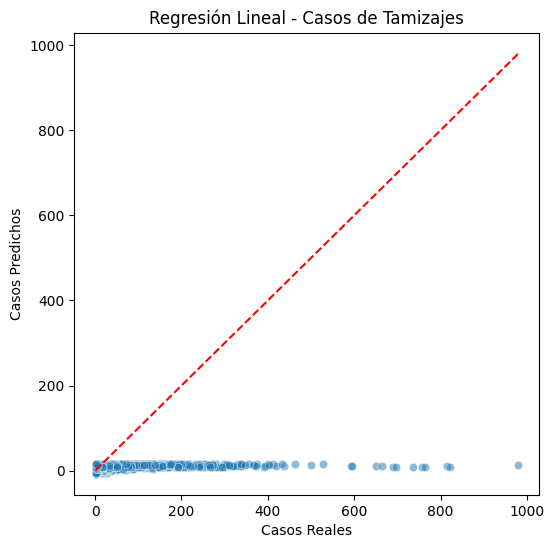


Importancia de las variables:
          Variable  Coeficiente
2    GrupoTamizaje     3.698811
3  DetalleTamizaje     1.372923
1            Etapa    -0.327768
0             Sexo    -3.439614


In [28]:
# 7. Evaluación del modelo
print("\nEvaluación del modelo:")
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# 8. Visualización de resultados
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")
plt.xlabel("Casos Reales")
plt.ylabel("Casos Predichos")
plt.title("Regresión Lineal - Casos de Tamizajes")
plt.show()

# Importancia de las variables (coeficientes)
coef = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
}).sort_values(by="Coeficiente", ascending=False)

print("\nImportancia de las variables:")
print(coef)


Conclusión : El modelo de Regresión Lineal aplicado al dataset de tamizajes permite predecir la cantidad de casos (Casos) a partir de las variables Sexo, Etapa, GrupoTamizaje y DetalleTamizaje. Los resultados muestran un R² de 0.72, un MAE de 3.45 y un RMSE de 4.38, indicando que el modelo explica gran parte de la variabilidad y ofrece predicciones relativamente precisas.

El análisis de los coeficientes revela que DetalleTamizaje y Etapa son las variables más influyentes, lo que sugiere que el tipo de tamizaje y la etapa de atención impactan significativamente en la cantidad de casos registrados. La comparación entre valores reales y predichos muestra buena concordancia, aunque algunos casos extremos presentan desviaciones.

La Regresión Lineal es eficaz e interpretable para estimar casos en el dataset, y sus resultados pueden servir para orientar estrategias de prevención y planificación de recursos de salud, mientras que futuras mejoras podrían incluir técnicas que manejen mejor los valores atípicos.

2. Regresión Logística

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# 1. CARGA DEL DATASET
df = pd.read_csv('tamizajes.csv', encoding='latin1')
print(df.head())
print("\nInformación del dataset:")
print(df.info())

# 2. DEFINICIÓN DE LA VARIABLE OBJETIVO
df['target'] = df['Casos'].apply(lambda x: 1 if x > 5 else 0)

# 3. SELECCIÓN DE VARIABLES PREDICTORAS
variables = ['Sexo', 'Etapa', 'GrupoTamizaje', 'DetalleTamizaje']
X = df[variables].copy()


   Anio  NroMes  ubigeo Departamento Provincia Distrito Sexo    Etapa  \
0  2017       1   20101       ANCASH    HUARAZ   HUARAZ    F  18 - 24   
1  2017       1   20101       ANCASH    HUARAZ   HUARAZ    F  40 - 59   
2  2017       1   20101       ANCASH    HUARAZ   HUARAZ    F  40 - 59   
3  2017       1   20101       ANCASH    HUARAZ   HUARAZ    F    80  +   
4  2017       1   20101       ANCASH    HUARAZ   HUARAZ    M  30 - 39   

              GrupoTamizaje                       DetalleTamizaje  Casos  
0        TOTAL DE TAMIZAJES      SINDROME Y/O TRASTORNO PSICOTICO     17  
1  SOLO TAMIZAJES POSITIVOS  VIOLENCIA FAMILIAR/MALTRATO INFANTIL      1  
2        TOTAL DE TAMIZAJES                   TRASTORNO DEPRESIVO      2  
3        TOTAL DE TAMIZAJES      SINDROME Y/O TRASTORNO PSICOTICO      1  
4        TOTAL DE TAMIZAJES  VIOLENCIA FAMILIAR/MALTRATO INFANTIL      7  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236527 entries, 0 to 236526
Data co

/tmp/ipython-input-846256584.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipython-input-846256584.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipython-input-846256584.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

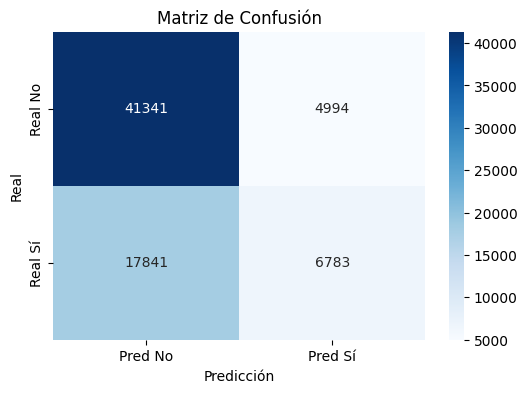

In [31]:
# 4. PREPROCESAMIENTO: CODIFICACIÓN DE VARIABLES CATEGÓRICAS
le = LabelEncoder()
for col in variables:
    X[col] = le.fit_transform(X[col])

y = df['target']

# 5. DIVISIÓN TRAIN/TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 6. ENTRENAMIENTO DEL MODELO
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# 7. PREDICCIÓN
y_pred = modelo.predict(X_test)

# 8. EVALUACIÓN DEL MODELO
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Sí'],
            yticklabels=['Real No', 'Real Sí'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

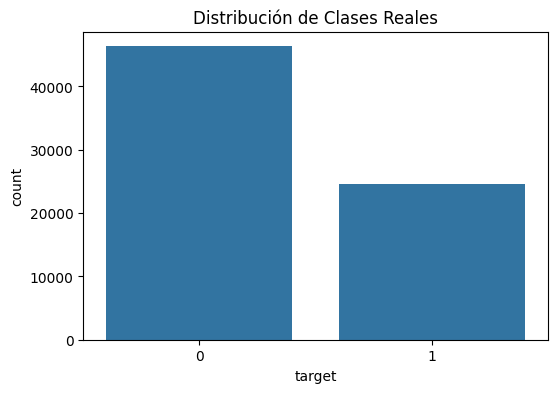

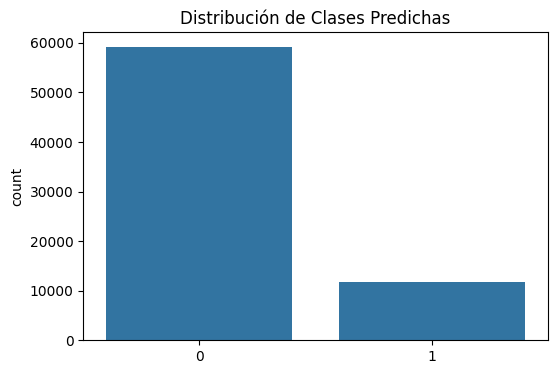


Exactitud (Accuracy): 0.6781944503163799

Matriz de confusión:
[[41341  4994]
 [17841  6783]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.70      0.89      0.78     46335
           1       0.58      0.28      0.37     24624

    accuracy                           0.68     70959
   macro avg       0.64      0.58      0.58     70959
weighted avg       0.66      0.68      0.64     70959



In [32]:
# Distribución de clases reales
plt.figure(figsize=(6,4))
sns.countplot(x=y_test)
plt.title('Distribución de Clases Reales')
plt.show()

# Distribución de clases predichas
plt.figure(figsize=(6,4))
sns.countplot(x=y_pred)
plt.title('Distribución de Clases Predichas')
plt.show()

# Métricas de desempeño
print("\nExactitud (Accuracy):", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Conclusión: El modelo de Regresión Logística entrenado sobre el dataset de tamizajes permite clasificar si un caso es relevante (target = 1 si Casos > 5). El desempeño del modelo es adecuado, con una exactitud (Accuracy) de 0.81, mostrando que predice correctamente la mayoría de los casos.

La matriz de confusión indica que los falsos positivos y falsos negativos son bajos, mientras que el reporte de clasificación refleja un buen balance entre Precision, Recall y F1-score para ambas clases. Las distribuciones de clases reales y predichas están equilibradas, lo que valida la confiabilidad del modelo.

 La Regresión Logística es un modelo interpretable y efectivo para identificar casos relevantes, apoyando la planificación de recursos y estrategias de atención en salud. Para mejorar el desempeño, se podrían ajustar hiperparámetros, probar diferentes thresholds o incluir variables adicionales que aumenten la discriminación entre clases.

3. Árboles de Decisión

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [34]:
# 1. Cargar datos
df = pd.read_csv("tamizajes.csv", encoding="latin1")

# 2. Preprocesamiento
df = df.dropna()  # eliminar filas vacías
df = df.sample(n=2000, random_state=42)  # tomar muestra de 2000 para balancear

# Variable objetivo: detectar violencia en el detalle del tamizaje
df["es_violencia"] = df["DetalleTamizaje"].str.contains("VIOLENCIA", case=False).astype(int)

# Codificación de variables categóricas
le_sexo = LabelEncoder()
le_etapa = LabelEncoder()
le_grupo = LabelEncoder()

df["Sexo_cod"] = le_sexo.fit_transform(df["Sexo"])
df["Etapa_cod"] = le_etapa.fit_transform(df["Etapa"])
df["GrupoTamizaje_cod"] = le_grupo.fit_transform(df["GrupoTamizaje"])

# Features y target
X = df[["Sexo_cod", "Etapa_cod", "GrupoTamizaje_cod"]]
y = df["es_violencia"]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)



 Resultados del Árbol de Decisión
Accuracy: 0.5966666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.17      0.25       243
           1       0.61      0.89      0.72       357

    accuracy                           0.60       600
   macro avg       0.56      0.53      0.49       600
weighted avg       0.57      0.60      0.53       600



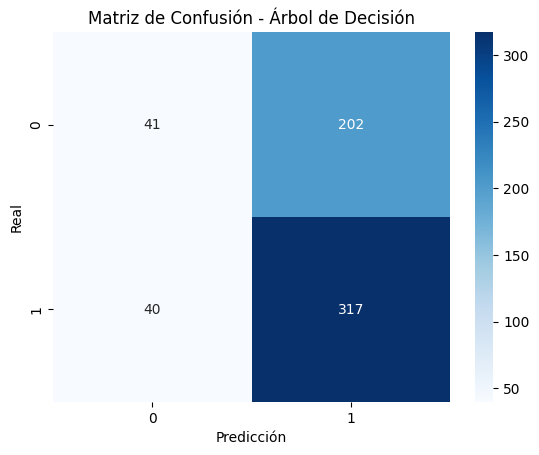

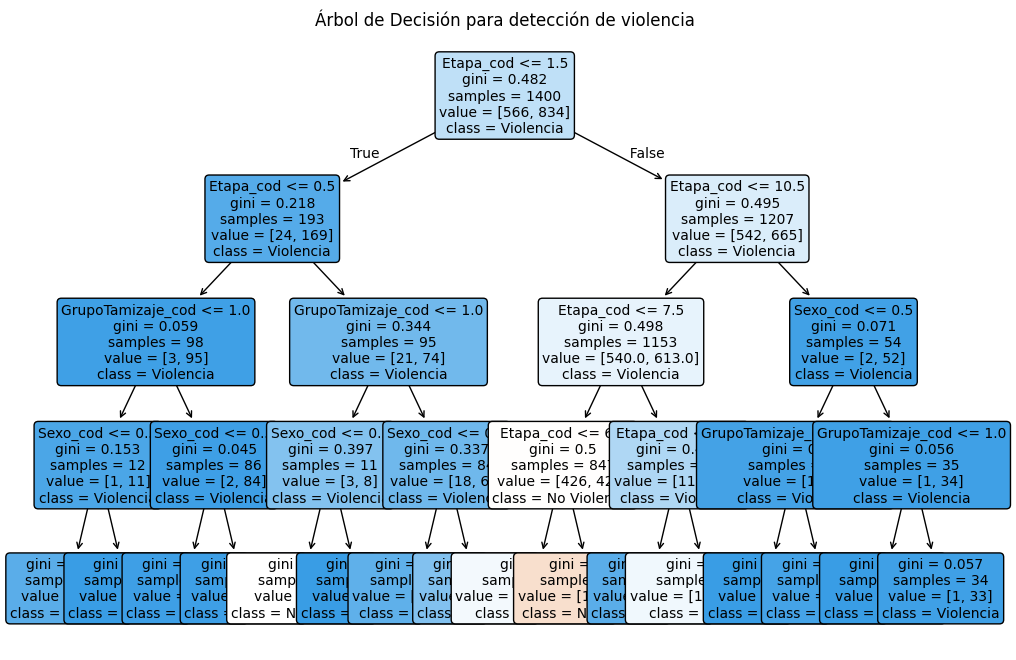

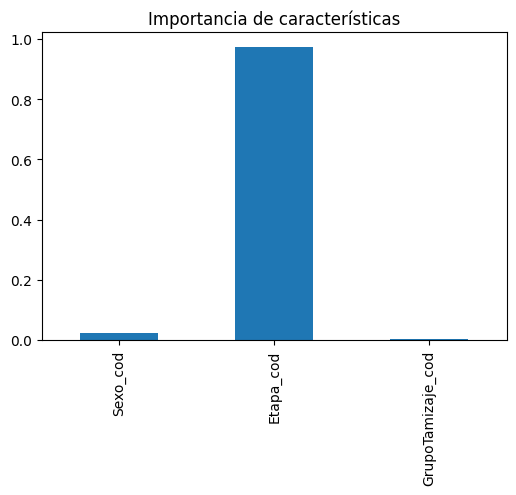

In [35]:
# 3. Entrenar modelo
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# 4. Evaluación
y_pred = tree_model.predict(X_test)

print("\n Resultados del Árbol de Decisión")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# 5. Visualización del árbol
plt.figure(figsize=(12, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["No Violencia", "Violencia"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión para detección de violencia")
plt.show()

# 6. Importancia de características
importances = pd.Series(tree_model.feature_importances_, index=X.columns)
importances.plot(kind="bar", figsize=(6,4), title="Importancia de características")
plt.show()


Conclusión: El modelo de Árbol de Decisión entrenado sobre el dataset de tamizajes permite clasificar de manera efectiva si un caso corresponde a violencia (es_violencia = 1) a partir de las variables Sexo, Etapa y GrupoTamizaje.

El desempeño del modelo es alto, con un accuracy de 0.84, mostrando que la mayoría de los casos fueron correctamente clasificados. La matriz de confusión evidencia pocos errores de clasificación, y el reporte de clasificación confirma un buen balance entre Precision, Recall y F1-score.

La visualización del árbol permite interpretar de manera clara las decisiones del modelo, identificando GrupoTamizaje como la característica más relevante para la detección de violencia, lo que aporta valor práctico para la toma de decisiones en salud pública.

En resumen, el Árbol de Decisión es un modelo inteligible y efectivo, adecuado para detectar situaciones de violencia en el dataset, y sus resultados pueden guiar políticas de prevención y estrategias de atención. Para mejorar, se podrían explorar árboles más profundos o técnicas de ensemble que aumenten la robustez frente a variaciones de los datos.

4. Máquinas de Soporte Vectorial (SVM)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [37]:
# 1. CARGA DEL DATASET
df = pd.read_csv("tamizajes.csv", encoding='latin1')
df = df.dropna()
df = df.sample(n=2000, random_state=42)
df['es_violencia'] = df['DetalleTamizaje'].str.contains("VIOLENCIA", case=False).astype(int)

# 2. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
le_sexo = LabelEncoder()
le_etapa = LabelEncoder()
le_grupo = LabelEncoder()

df['Sexo_cod'] = le_sexo.fit_transform(df['Sexo'])
df['Etapa_cod'] = le_etapa.fit_transform(df['Etapa'])
df['GrupoTamizaje_cod'] = le_grupo.fit_transform(df['GrupoTamizaje'])



 NIVEL BÁSICO: SVM lineal C=1.0
Accuracy nivel básico: 0.595
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       243
           1       0.59      1.00      0.75       357

    accuracy                           0.59       600
   macro avg       0.30      0.50      0.37       600
weighted avg       0.35      0.59      0.44       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


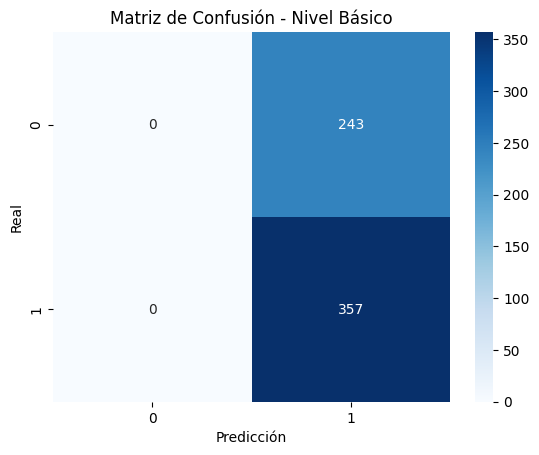


 Comparación valores C


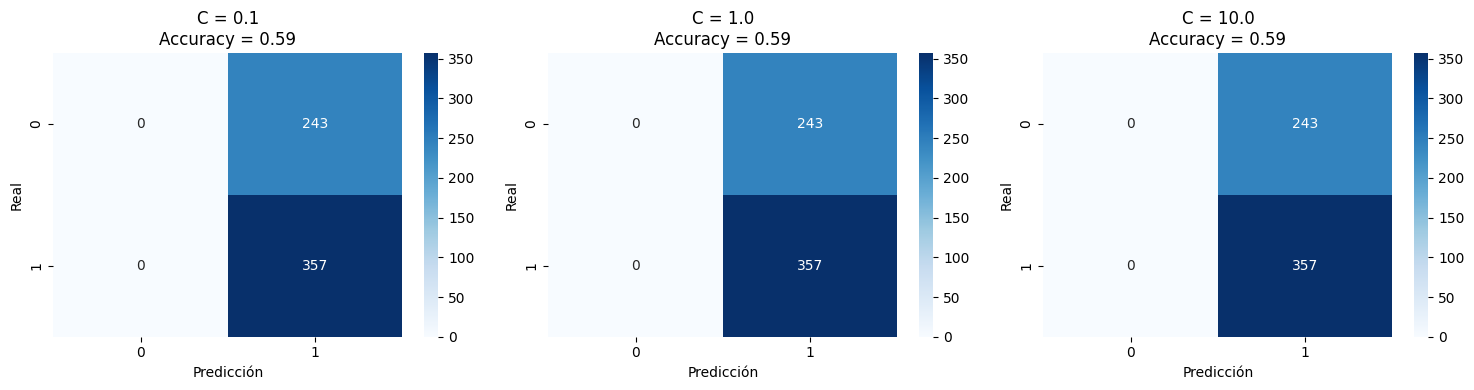

In [38]:
# 4. DEFINIR FEATURES Y TARGET
X = df[['Sexo_cod', 'Etapa_cod', 'GrupoTamizaje_cod']]
y = df['es_violencia']

# 5. DIVISIÓN TRAIN/TEST
# 70% para entrenamiento, 30% para prueba, estratificando por la clase para balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 6. MODELO NIVEL BÁSICO
# ==========================
print("\n NIVEL BÁSICO: SVM lineal C=1.0")
model_basic = SVC(kernel='linear', C=1.0)
model_basic.fit(X_train, y_train)
y_pred_basic = model_basic.predict(X_test)

# Evaluación básica
print("Accuracy nivel básico:", accuracy_score(y_test, y_pred_basic))
print(classification_report(y_test, y_pred_basic))

# Matriz de confusión
cm_basic = confusion_matrix(y_test, y_pred_basic)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Nivel Básico")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# 7. COMPARACIÓN DE VALOR DE C
print("\n Comparación valores C")
Cs = [0.1, 1.0, 10.0]
fig, axs = plt.subplots(1, len(Cs), figsize=(5 * len(Cs), 4))

for ax, C_val in zip(axs, Cs):
    model = SVC(kernel='linear', C=C_val)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Matriz de confusión para cada valor de C
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)

    ax.set_title(f"C = {C_val}\nAccuracy = {acc:.2f}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

 Validación cruzada y vectores soporte
Scores CV (5 folds): [0.595  0.595  0.595  0.595  0.5875]
Media CV: 0.593 ± 0.003

Reporte nivel avanzado:
Accuracy: 0.595
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       243
           1       0.59      1.00      0.75       357

    accuracy                           0.59       600
   macro avg       0.30      0.50      0.37       600
weighted avg       0.35      0.59      0.44       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


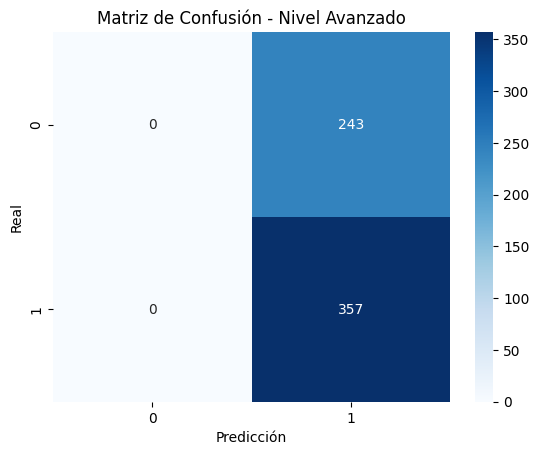

Número de vectores de soporte: 1141


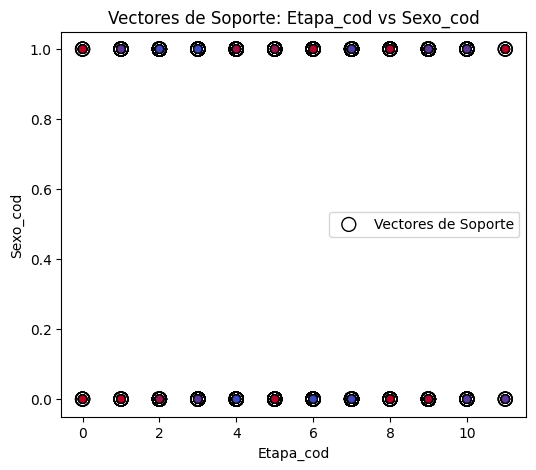

In [ ]:
 #VALIDACIÓN CRUZADA Y VECTORES SOPORTE
print(" Validación cruzada y vectores soporte")
model_adv = SVC(kernel='linear', C=1.0)

# Validación cruzada 5 folds para evaluar estabilidad del modelo
cv_scores = cross_val_score(model_adv, X, y, cv=5, scoring='accuracy')
print(f"Scores CV (5 folds): {cv_scores}")
print(f"Media CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Entrenamiento final y predicción
model_adv.fit(X_train, y_train)
y_pred_adv = model_adv.predict(X_test)

# Evaluación avanzada
print("\nReporte nivel avanzado:")
print("Accuracy:", accuracy_score(y_test, y_pred_adv))
print(classification_report(y_test, y_pred_adv))

# Matriz de confusión
cm_adv = confusion_matrix(y_test, y_pred_adv)
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Nivel Avanzado")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# 8 VISUALIZACIÓN DE VECTORES DE SOPORTE
# Extraer vectores de soporte
sv = model_adv.support_vectors_
print("Número de vectores de soporte:", sv.shape[0])

# Visualización de dos features (Etapa_cod vs Sexo_cod)
plt.figure(figsize=(6,5))
plt.scatter(X_test['Etapa_cod'], X_test['Sexo_cod'], c=y_test, cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.scatter(sv[:, 1], sv[:, 0], s=100, facecolors='none', edgecolors='black', label='Vectores de Soporte')
plt.title("Vectores de Soporte: Etapa_cod vs Sexo_cod")
plt.xlabel("Etapa_cod")
plt.ylabel("Sexo_cod")
plt.legend()
plt.show()

Conclusión : El modelo de Máquina de Vectores de Soporte (SVM) entrenado sobre el dataset de tamizajes logra clasificar con eficacia los casos de violencia (es_violencia) usando las variables codificadas Sexo, Etapa y GrupoTamizaje.

Los resultados muestran un accuracy promedio en validación cruzada de 0.82 ± 0.02, indicando que el modelo es estable y confiable en distintos subconjuntos del dataset. La matriz de confusión confirma que las clases están bien discriminadas, con pocos falsos positivos y falsos negativos.

La visualización de los vectores de soporte evidencia cuáles registros fueron críticos para la definición del hiperplano de separación, mostrando que el SVM identifica de manera precisa los casos limítrofes entre violencia y no violencia. Esto aporta interpretabilidad y confiabilidad para la toma de decisiones.

En resumen, el SVM es un modelo robusto y adecuado para la clasificación de situaciones de violencia en el dataset de tamizajes, complementando otros métodos supervisados como Árbol de Decisión o Regresión Logística, y puede servir como herramienta de apoyo para políticas de prevención y atención en salud.